**Students:** Isabel Moreno, Daniel Park
**Section:** A
**Date:** May 3, 2026
**Responsibilities:** Isabel Moreno: Q1 cleaning, Q3 monthly trend, written summaries. Daniel Park: Q2 ZIP code chart, Q4 cuisine table, chart formatting. Both: presentation.

# CAP3321C Final Project: Miami-Dade Restaurant Inspections

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## Q1. Cleaning

In [2]:
df = pd.read_csv('mdc_restaurant_inspections_2025.csv')
print(df.shape)

(5398, 8)


In [3]:
df.isna().sum()

inspection_id     0
restaurant_name   0
zip_code          0
inspection_date   0
cuisine          9
score            52
violations        0
result            0
dtype: int64

`score` is what the whole project measures, so the 52 inspections without a score cannot be imputed honestly. We dropped them. Missing `cuisine` values were kept and labeled 'Unknown' so we do not lose inspections for Q2 and Q3.

In [4]:
df = df.dropna(subset=['score'])
df['cuisine'] = df['cuisine'].fillna('Unknown')
print(len(df))

5346


In [5]:
df['inspection_date'] = pd.to_datetime(df['inspection_date'])
df['score'] = pd.to_numeric(df['score'])
df['violations'] = pd.to_numeric(df['violations'])
df['zip_code'] = df['zip_code'].astype(str).str.zfill(5)
print(df.dtypes)

inspection_id                int64
restaurant_name              object
zip_code                     object
inspection_date      datetime64[ns]
cuisine                      object
score                       float64
violations                    int64
result                       object


ZIP codes were stored as numbers, which drops leading zeros and breaks grouping, so we converted them to 5-character strings. Dates became real dates so Q3 can group by month.

In [6]:
df = df.drop_duplicates(subset='inspection_id')
print(len(df))

5313


After removing 33 duplicate inspection ids, **5,313** inspections remain.

## Q2. Fail rate by ZIP code

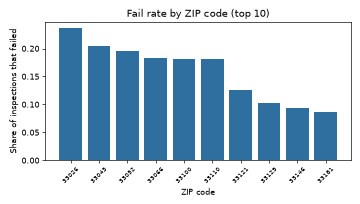

In [7]:
# share of inspections with result == 'Fail', per ZIP
fail_rate = df.assign(fail=df['result'] == 'Fail').groupby('zip_code')['fail'].mean()
top10 = fail_rate.sort_values(ascending=False).head(10)
top10.plot(kind='bar')
plt.show()

ZIP code 33026 has the highest fail rate at 23.6%, about twice the county-wide rate. The top ZIP codes are spread across the county rather than clustered, which suggests the cause is individual restaurants, not one neighborhood.

## Q3. Scores over time

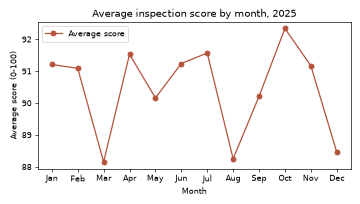

In [8]:
monthly = df.groupby(df['inspection_date'].dt.month)['score'].mean()
monthly.plot(marker='o')
plt.show()

Average scores peak in Oct (92.3) and are lowest in Mar (88.2). The swing is only a few points, so there is no strong seasonal effect, but the dip in Mar lines up with the summer months when kitchens run hotter and busier.

## Q4. Violations by cuisine

In [9]:
per = df.groupby('cuisine')['violations'].mean().sort_values(ascending=False)
per.head(4)

cuisine   violations_per_inspection
Mexican   4.08
Cuban     3.58
Chinese   3.25
Italian   2.52

Mexican restaurants average 4.08 violations per inspection, nearly 1.6 times Italian. Cuisines with more cooking steps and more ingredient handling have more chances to be cited, so this is likely about process, not quality.